(7043, 16)
X_train shape: (5634, 15)
X_test shape: (1409, 15)


Logistic Regression

Accuracy Score: 0.7331

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



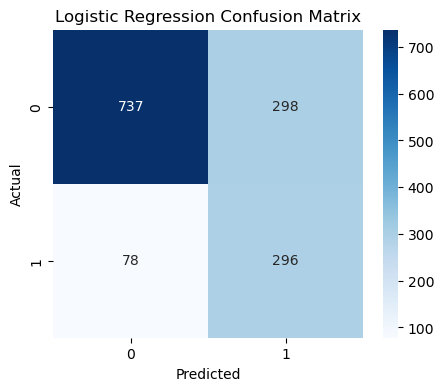



Decision Tree

Accuracy Score: 0.7218

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.48      0.51      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409



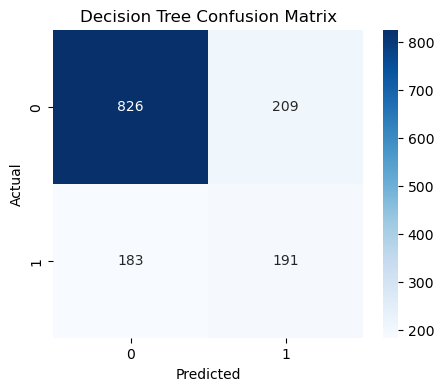



Random Forest

Accuracy Score: 0.7835

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



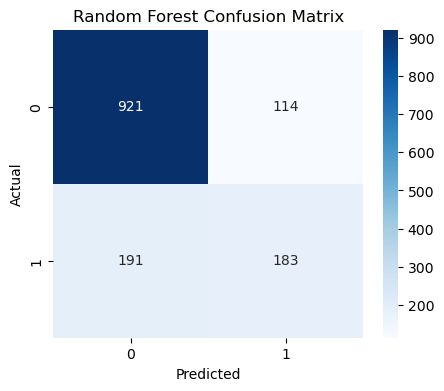


Logistic Regression ROC-AUC: 0.8424423260740397
Decision Tree ROC-AUC: 0.653199514324834
Random Forest ROC-AUC: 0.8150972642021237

Top Important Features:

                           Feature  Importance
0                     TotalCharges    0.178164
3                   MonthlyCharges    0.164712
1                AvgChargePerMonth    0.162682
2                           tenure    0.147011
4          Contract_Month-to-month    0.065811
5                OnlineSecurity_No    0.044569
10     InternetService_Fiber optic    0.040047
7                   TechSupport_No    0.035758
6   PaymentMethod_Electronic check    0.033036
8                           gender    0.024415
13                 OnlineBackup_No    0.024065
9                 PaperlessBilling    0.023871
11                         Partner    0.021201
14                      Dependents    0.017751
12               Contract_Two year    0.016907


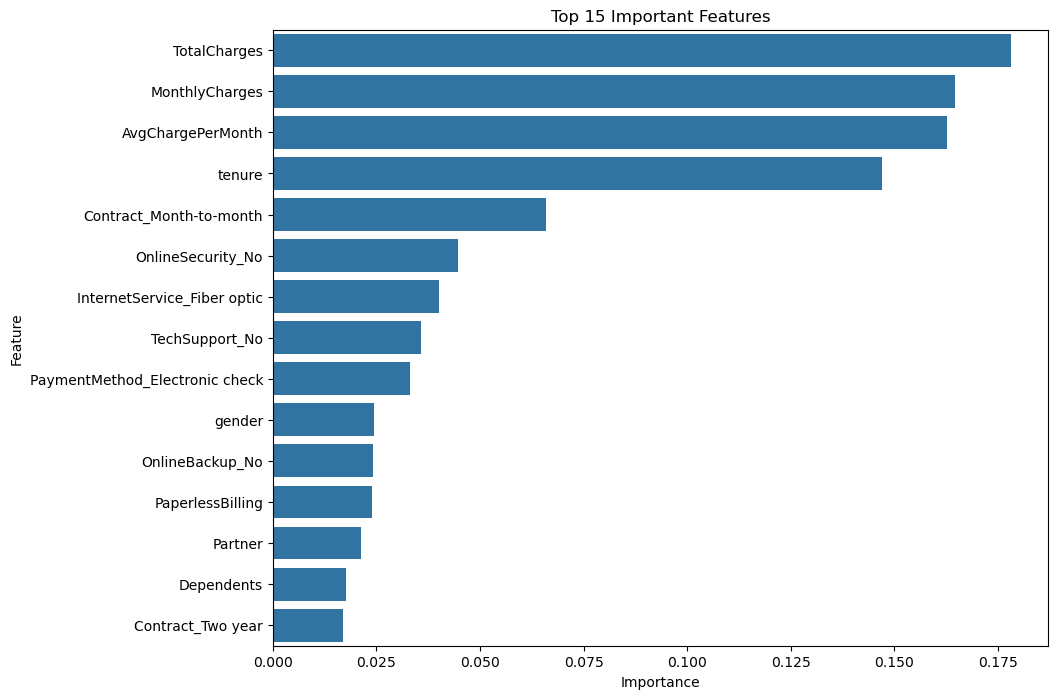


Model Saved Successfully


In [1]:
# =========================================
# CUSTOMER CHURN - MODEL TRAINING
# =========================================

# ========= 1. IMPORT LIBRARIES =========

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


# ========= 2. LOAD DATA =========

df = pd.read_csv("processed_data.csv")

print(df.shape)

df.head()


# ========= 3. FEATURES & TARGET =========

X = df.drop('Churn', axis=1)

y = df['Churn']


# ========= 4. TRAIN TEST SPLIT =========

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


# ========= 5. HANDLE BOOLEAN COLUMNS =========

bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)

X_test[bool_cols] = X_test[bool_cols].astype(int)


# ========= 6. SCALING =========

num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'AvgChargePerMonth'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)


# =========================================
# 7. LOGISTIC REGRESSION
# =========================================

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


# =========================================
# 8. DECISION TREE
# =========================================

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


# =========================================
# 9. RANDOM FOREST
# =========================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


# =========================================
# 10. EVALUATION FUNCTION
# =========================================

def evaluate_model(y_test, y_pred, model_name):

    print("\n")
    print("="*50)

    print(model_name)

    print("="*50)

    # Accuracy

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score: {accuracy:.4f}")

    # Classification Report

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # Confusion Matrix

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()


# =========================================
# 11. EVALUATE MODELS
# =========================================

evaluate_model(
    y_test,
    y_pred_lr,
    "Logistic Regression"
)

evaluate_model(
    y_test,
    y_pred_dt,
    "Decision Tree"
)

evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)


# =========================================
# 12. ROC AUC SCORE
# =========================================

# Logistic Regression

lr_probs = lr.predict_proba(X_test)[:,1]

lr_roc = roc_auc_score(y_test, lr_probs)

print("\nLogistic Regression ROC-AUC:", lr_roc)


# Decision Tree

dt_probs = dt.predict_proba(X_test)[:,1]

dt_roc = roc_auc_score(y_test, dt_probs)

print("Decision Tree ROC-AUC:", dt_roc)


# Random Forest

rf_probs = rf.predict_proba(X_test)[:,1]

rf_roc = roc_auc_score(y_test, rf_probs)

print("Random Forest ROC-AUC:", rf_roc)


# =========================================
# 13. FEATURE IMPORTANCE
# =========================================

importance_df = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': rf.feature_importances_

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:\n")

print(importance_df.head(15))


# ========= FEATURE IMPORTANCE PLOT =========

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)

plt.title("Top 15 Important Features")

plt.show()


# =========================================
# 14. SAVE MODEL
# =========================================
import joblib
joblib.dump(lr, "churn_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("\nModel Saved Successfully")

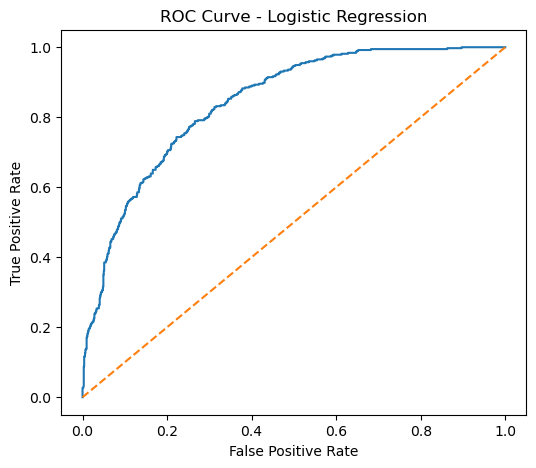

In [2]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, lr_probs)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [3]:
import joblib

joblib.dump(X_train.columns.tolist(), "features.pkl")

['features.pkl']